In [6]:
# ============================================================
# STEP 1 — Data Loading & Cleaning
# ============================================================

import pandas as pd

# 1. Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# 2. Drop junk columns
df = df[['v1', 'v2']]

# 3. Rename columns
df.columns = ['label', 'message']

# 4. Encode label (ham=0, spam=1)
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# 5. Check for nulls & duplicates
print("Shape:", df.shape)
print("Nulls:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Label distribution:\n", df['label'].value_counts())

# 6. Drop duplicates
df = df.drop_duplicates()
print("\nShape after dedup:", df.shape)
print("Label distribution after dedup:\n", df['label'].value_counts())

Shape: (5572, 3)
Nulls:
 label            0
message          0
label_encoded    0
dtype: int64
Duplicates: 403
Label distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

Shape after dedup: (5169, 3)
Label distribution after dedup:
 label
ham     4516
spam     653
Name: count, dtype: int64


       msg_length  word_count  char_count
label                                    
ham         70.46       14.13       57.20
spam       137.89       23.68      115.16

Top spam words: [('call', 309), ('you', 268), ('your', 242), ('free', 195), ('for', 184), ('the', 183), ('now', 164), ('txt', 134), ('from', 122), ('have', 115), ('mobile', 109), ('stop', 109), ('text', 108), ('and', 104), ('claim', 96)]

Top ham words: [('you', 1875), ('the', 1051), ('and', 825), ('that', 537), ('for', 476), ('have', 423), ('can', 419), ('but', 414), ('are', 397), ('not', 389), ('your', 381), ('will', 315), ('how', 298), ('get', 297), ('now', 282)]


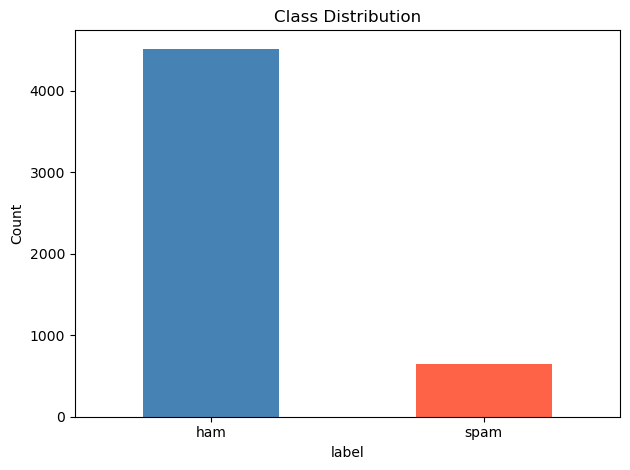

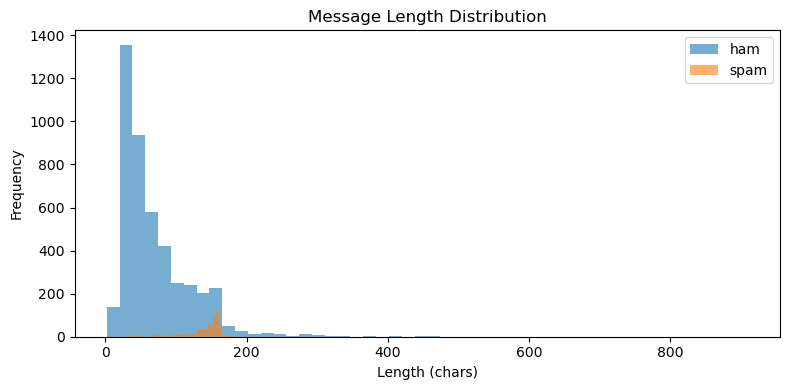

In [7]:
# ============================================================
# STEP 2 — Exploratory Data Analysis (EDA)
# ============================================================

import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --- Feature engineering for EDA ---
df['msg_length'] = df['message'].apply(len)
df['word_count']  = df['message'].apply(lambda x: len(x.split()))
df['char_count']  = df['message'].apply(lambda x: len(x.replace(' ', '')))

# --- Stats by label ---
print(df.groupby('label')[['msg_length','word_count','char_count']].mean().round(2))

# --- Top words per class ---
def get_top_words(subset, n=15):
    all_words = []
    for msg in subset:
        words = re.findall(r'\b[a-zA-Z]{3,}\b', msg.lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

print("\nTop spam words:", get_top_words(df[df['label']=='spam']['message']))
print("\nTop ham words:",  get_top_words(df[df['label']=='ham']['message']))

# --- Class distribution plot ---
df['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# --- Message length distribution ---
df.groupby('label')['msg_length'].plot(kind='hist', bins=50,
    alpha=0.6, legend=True, figsize=(8,4))
plt.title('Message Length Distribution')
plt.xlabel('Length (chars)')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 3 — Text Preprocessing
# ============================================================

import re
import string

STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it',
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were',
    'be','been','being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down','in',
    'out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more',
    'most','other','some','such','no','nor','not','only','own','same','so',
    'than','too','very','s','t','can','will','just','don','should','now',
    'd','ll','m','o','re','ve','y','ain','aren','couldn','didn','doesn',
    'hadn','hasn','haven','isn','ma','mightn','mustn','needn','shan',
    'shouldn','wasn','weren','won','wouldn'
])

def preprocess(text):
    text = text.lower()                                         # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)                 # 2. Remove URLs
    text = re.sub(r'\d+', '', text)                            # 3. Remove numbers
    text = text.translate(str.maketrans('','', string.punctuation))  # 4. Remove punctuation
    tokens = text.split()                                       # 5. Tokenize
    tokens = [t for t in tokens if t not in STOPWORDS          # 6. Remove stopwords
              and len(t) > 1]
    return ' '.join(tokens)                                     # 7. Rejoin

df['cleaned'] = df['message'].apply(preprocess)

# Verify
print("Avg tokens BEFORE:", df['message'].apply(lambda x: len(x.split())).mean().round(2))
print("Avg tokens AFTER: ", df['cleaned'].apply(lambda x: len(x.split())).mean().round(2))
print("\nSample:\n", df[['label','message','cleaned']].head(3))

Avg tokens BEFORE: 15.34
Avg tokens AFTER:  8.45

Sample:
   label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   

                                             cleaned  
0  go jurong point crazy available bugis great wo...  
1                              ok lar joking wif oni  
2  free entry wkly comp win fa cup final tkts st ...  


In [9]:
# ============================================================
# STEP 4 — Feature Engineering (TF-IDF / Bag of Words)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# --- Using TF-IDF Vectorizer ---
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['cleaned'])

print("TF-IDF Shape:", X_tfidf.shape)
print("Feature names sample:", tfidf.get_feature_names_out()[:10])

# --- Alternative: Count Vectorizer (Bag of Words) ---
# bow = CountVectorizer(max_features=5000, min_df=2, max_df=0.8)
# X_bow = bow.fit_transform(df['cleaned'])
# print("BoW Shape:", X_bow.shape)

# Prepare target variable
y = df['label_encoded'].values

print("\nFeature matrix shape:", X_tfidf.shape)
print("Target distribution:\n", df['label_encoded'].value_counts())


TF-IDF Shape: (5169, 5000)
Feature names sample: ['aah' 'abi' 'ability' 'abiola' 'abj' 'able' 'able come' 'able deliver'
 'able get' 'able pay']

Feature matrix shape: (5169, 5000)
Target distribution:
 label_encoded
0    4516
1     653
Name: count, dtype: int64


In [10]:
# ============================================================
# STEP 5 — Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# --- Split data (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nTraining label distribution:\n", pd.Series(y_train).value_counts())
print("\nTest label distribution:\n", pd.Series(y_test).value_counts())


Training set size: (4135, 5000)
Test set size:     (1034, 5000)

Training label distribution:
 0    3613
1     522
Name: count, dtype: int64

Test label distribution:
 0    903
1    131
Name: count, dtype: int64


In [11]:
# ============================================================
# STEP 6 — Model Training (Multiple Classifiers)
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import time

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='linear', random_state=42)
}

trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    trained_models[name] = model
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    print(f"Training Time: {end-start:.3f}s")
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy:     {test_score:.4f}")

print(f"\n{'='*50}")
print("All models trained successfully!")
print(f"{'='*50}")



Training Naive Bayes...
Training Time: 0.004s
Training Accuracy: 0.9775
Test Accuracy:     0.9671

Training Logistic Regression...
Training Time: 0.024s
Training Accuracy: 0.9659
Test Accuracy:     0.9449

Training Random Forest...
Training Time: 0.340s
Training Accuracy: 0.9998
Test Accuracy:     0.9700

Training SVM...
Training Time: 0.299s
Training Accuracy: 0.9915
Test Accuracy:     0.9768

All models trained successfully!



Naive Bayes
Accuracy:  0.9671
Precision: 0.9899
Recall:    0.7481
F1-Score:  0.8522

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



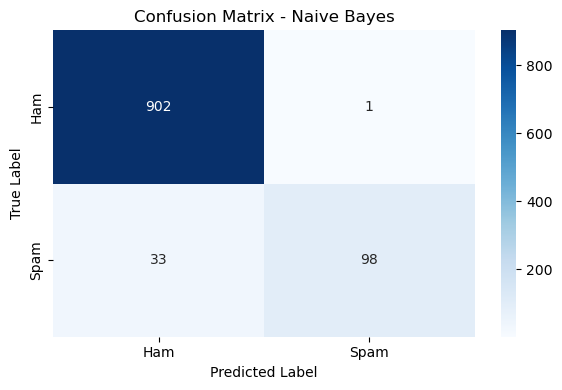


Logistic Regression
Accuracy:  0.9449
Precision: 0.9868
Recall:    0.5725
F1-Score:  0.7246

Classification Report:
              precision    recall  f1-score   support

         Ham       0.94      1.00      0.97       903
        Spam       0.99      0.57      0.72       131

    accuracy                           0.94      1034
   macro avg       0.96      0.79      0.85      1034
weighted avg       0.95      0.94      0.94      1034



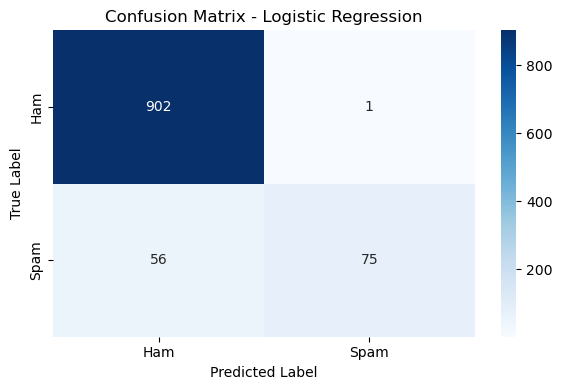


Random Forest
Accuracy:  0.9700
Precision: 1.0000
Recall:    0.7634
F1-Score:  0.8658

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



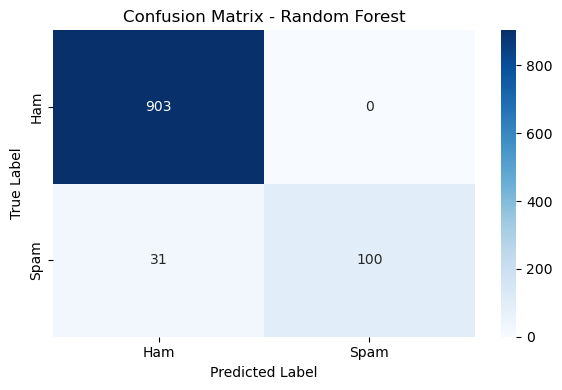


SVM
Accuracy:  0.9768
Precision: 0.9820
Recall:    0.8321
F1-Score:  0.9008

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034



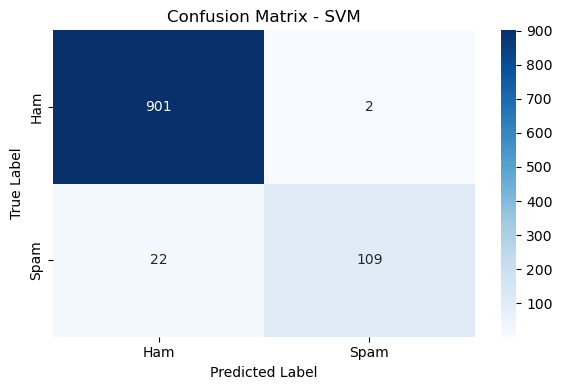


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
        Naive Bayes  0.967118   0.989899 0.748092  0.852174
Logistic Regression  0.944874   0.986842 0.572519  0.724638
      Random Forest  0.970019   1.000000 0.763359  0.865801
                SVM  0.976789   0.981982 0.832061  0.900826


In [12]:
# ============================================================
# STEP 7 — Model Evaluation (Metrics & Confusion Matrix)
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Ham', 'Spam'])}")
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# --- Results Comparison ---
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))


In [13]:
# ============================================================
# STEP 8 — Handling Class Imbalance (SMOTE & Class Weights)
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- Check class imbalance ---
print("Original class distribution:")
print(pd.Series(y_train).value_counts())
print(f"Imbalance ratio: {pd.Series(y_train).value_counts()[0] / pd.Series(y_train).value_counts()[1]:.2f}:1")

# --- Method 1: SMOTE (Synthetic Minority Over-sampling) ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# --- Method 2: Class weights ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"\nClass Weights: {class_weight_dict}")

# --- Retrain models with balanced data ---
print("\n" + "="*60)
print("Retraining Logistic Regression with SMOTE...")
print("="*60)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"Accuracy (SMOTE): {acc_smote:.4f}")
print(f"F1-Score (SMOTE): {f1_smote:.4f}")

print("\n" + "="*60)
print("Retraining Logistic Regression with class weights...")
print("="*60)

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_weighted.fit(X_train, y_train)

y_pred_weighted = lr_weighted.predict(X_test)
acc_weighted = accuracy_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)

print(f"Accuracy (Weighted): {acc_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")


Original class distribution:
0    3613
1     522
Name: count, dtype: int64
Imbalance ratio: 6.92:1

After SMOTE:
0    3613
1    3613
Name: count, dtype: int64

Class Weights: {0: np.float64(0.5722391364517022), 1: np.float64(3.960727969348659)}

Retraining Logistic Regression with SMOTE...
Accuracy (SMOTE): 0.9720
F1-Score (SMOTE): 0.8889

Retraining Logistic Regression with class weights...
Accuracy (Weighted): 0.9681
F1-Score (Weighted): 0.8736


In [14]:
# ============================================================
# STEP 9 — Hyperparameter Tuning (Grid Search & Random Search)
# ============================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline

# --- Grid Search for Logistic Regression ---
print("="*60)
print("Grid Search: Logistic Regression")
print("="*60)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_lr.best_params_}")
print(f"Best CV F1-Score: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_tuned = best_lr.predict(X_test)
print(f"Test F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

# --- Random Search for Random Forest ---
print("\n" + "="*60)
print("Random Search: Random Forest")
print("="*60)

param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_rf.fit(X_train, y_train)

print(f"\nBest Parameters: {random_rf.best_params_}")
print(f"Best CV F1-Score: {random_rf.best_score_:.4f}")

best_rf = random_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print(f"Test F1-Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")

print("\n" + "="*60)
print("Hyperparameter tuning completed!")
print("="*60)


Grid Search: Logistic Regression
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-Score: 0.8955
Test F1-Score: 0.9016
Test Accuracy: 0.9768

Random Search: Random Forest
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1-Score: 0.8404
Test F1-Score: 0.8522
Test Accuracy: 0.9671

Hyperparameter tuning completed!


In [18]:
# --- Save metadata ---
metadata = {
    'model_name': 'Spam Classifier v1.0',
    'timestamp': timestamp,
    'accuracy': acc_final,
    'f1_score': f1_final,
    'features_used': final_pipeline.named_steps['tfidf'].get_feature_names_out().tolist()[:100],
    'num_features': len(final_pipeline.named_steps['tfidf'].get_feature_names_out()),
    'training_samples': len(df),
    'classes': ['Ham', 'Spam']
}

meta_path = f'model_metadata_{timestamp}.joblib'
joblib.dump(metadata, meta_path)
print(f"✓ Metadata saved: {meta_path}")


✓ Metadata saved: model_metadata_20260408_225239.joblib
